<div style="background-color: steelblue; padding: 10px; border-radius: 5px;">
    <p style="margin: 10;"></p>
    <h1 style="text-align: center; margin: 0; font-weight: bold; color: white;">SWOT OMIP : Plotting  spectrum  for global boxes</h1>
    <p style="margin: 10;"></p>
</div>



## 📦**Imports** 

In [1]:
%%time

##################################
#Imports

from datetime import datetime
import s3fs
import xarray as xr
import pyinterp
from widetrax import DataPreprocessing as dp
from widetrax import Spectra as sp
import numpy as np
import json
from watermark import watermark
import time
import platform
from shapely.geometry import shape, box

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
#from widetrax import Spectra as sp
import plot_psd1Xglobal1 as pp2X

CPU times: user 1.53 s, sys: 509 ms, total: 2.04 s
Wall time: 6.35 s


## **Define Season** 

In [2]:
# CONFIG
season="JAS"


## **Load boxes position**

In [3]:
# NOT MODIFY

roi = {
        "lon_min": -180,
        "lon_max": 180,
        "lat_min": -90,
        "lat_max": 90
}
pos_reg=[-180, -90, 180, 90]

with open("mostly_ocean_boxes_filtered.geojson") as f:
    data = json.load(f)

roi_poly = box(roi["lon_min"], roi["lat_min"],
               roi["lon_max"], roi["lat_max"])

selected = []

for feature in data["features"]:
    poly = shape(feature["geometry"])
    if poly.intersects(roi_poly):
        selected.append(poly)

## **Plotting**

Comments:
* The code is adapted to load JSON files locally, but it can be modified to load them from the S3 bucket.
* The code has a bug when plotting the first boxes.
* To keep the figure clear, not all boxes are included.
* The positions of the boxes need to be improved.

/Users/contrema/Documents/Postdoc/SWOTv2/plot_psd1Xglobal1.py:100: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))
/Users/contrema/Documents/Postdoc/SWOTv2/plot_psd1Xglobal1.py:100: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))
/Users/contrema/Documents/Postdoc/SWOTv2/plot_psd1Xglobal1.py:100: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))
/Users/contrema/Documents/Postdoc/SWOTv2/plot_psd1Xglobal1.py:100: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lambda x: 1 / x))
/Users/contrema/Documents/Postdoc/SWOTv2/plot_psd1Xglobal1.py:100: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("bottom", functions=(lambda x: 1 / x, lam

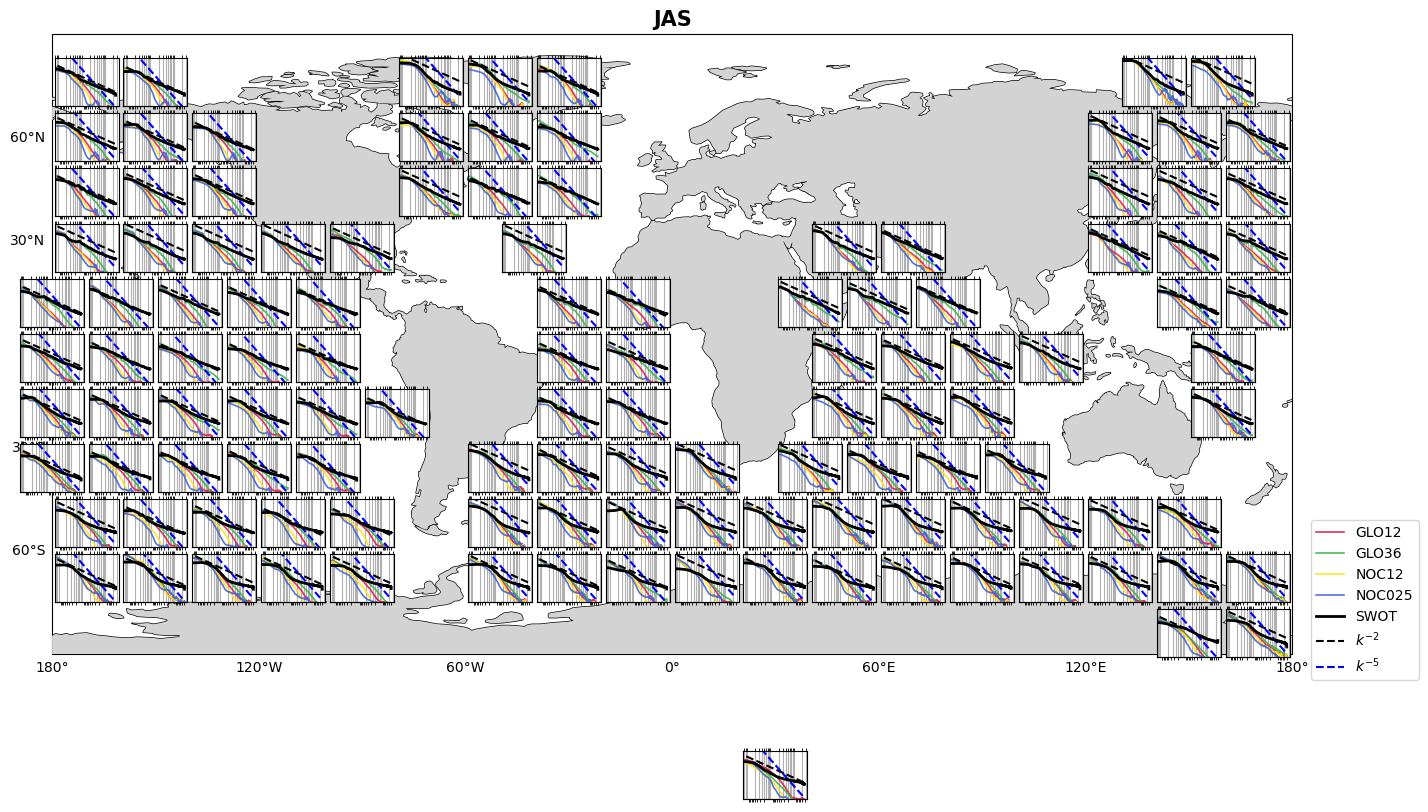

In [4]:


# Colors plot
colors = [
    "#E6194B",  # red
    "#3CB44B",  # green
    "#FFE119",  # yellow
    "#4363D8",  # blue
    "k"
    #"#F58231",  # orange
    #"#911EB4",  # purple
]

#MODEL LOAD
models=["GLO12","GLO36","NOC12","NOC025","SWOT"]

max_horizontal_gridsize = [0,0,0] #,2.224,2.224,25,7,0]

fig = plt.figure(figsize=(16, 12))
ax = plt.axes(projection=ccrs.PlateCarree())
#ax.set_extent(pos_reg, crs=ccrs.PlateCarree())
ax.set_global()
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=2,
    color='gray',
    alpha=0.5,
    linestyle='--'
)

# Optional: clean up label placement
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}
gl.xlines = False
gl.ylines = False
ax.set_title(season,fontsize=15, fontweight="bold", color="black")
ax.add_feature(cfeature.LAND,zorder=10, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE)

box=20
for i, poly in enumerate(selected[20:-20:2]):



    # Size of inset (tune this)

 
    # Box center
    lon_min, lat_min, lon_max, lat_max = poly.bounds
    lon_c = 0.5 * (lon_min + lon_max)
    lat_c = 0.8 * (lat_min + lat_max)

    # Convert lon/lat → figure coordinates
    x_fig, y_fig = ax.transData.transform(
        ccrs.PlateCarree().transform_point(lon_c-5, lat_c+20, ccrs.PlateCarree())
        )
    x_fig, y_fig = fig.transFigure.inverted().transform((x_fig, y_fig))
    w, h = 0.04, 0.04

    inset_ax = fig.add_axes([x_fig - w/2, y_fig - h/2, w, h])

    spectrum=[]
    freq=[]
    # Plot spectrum
    for imod in ["GLO12V4","GLO36V1","NOC12","NOC025","SWOT"]:
        filename = "GLOBALv2/" + imod +  "/Global_box_" + str(box) + "_" + season + "_" + imod + ".json"
        with open(filename, "r") as f:
            data = json.load(f)
        spectrum.append(data["Spectra"])
        freq.append(data["Frequency"])
        
    if box==22:
       pp2X.plot_psd(inset_ax, np.array(freq[0]).T,  psds = spectrum, unit = "m2",psd_labels=models,legend=True,bba_leg=(2.3,3),xtick_show=False, ytick_show=False,
                    xlabel_upper=False,xlabel_lower=False, ylabel=False,colors=colors,savefig=True, filename=("globa_" + season + ".png"),plot_transparent=False)

    else:
        pp2X.plot_psd(inset_ax, np.array(freq[0]).T,  psds = spectrum, unit = "m2",psd_labels=models,legend=False,xtick_show=False, ytick_show=False,
                    xlabel_upper=False,xlabel_lower=False, ylabel=False,colors=colors,savefig=True, filename=("globa_" + season + ".png"),plot_transparent=False)
    #del freq, spectrum
    box=box+2